In [5]:
#Code Block 1
## import libraries

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
%matplotlib inline

In [6]:
#Code Block 2
## load the cleaned data

data_clean = pd.read_csv('../../Data/Ramsey/cleaned/cleaned_mortgage_covenant_data-Ramsey.csv')
display(data_clean.head())
data_clean.info()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.705302e+10,Race Not Available,1,305000.0,325000.0,65.0,6.50,38.48,83.64,10,0.0,True,0
1,2023,2.700305e+10,White,1,285000.0,295000.0,72.0,6.45,21.74,86.21,10,0.0,True,0
2,2023,2.703706e+10,White,1,365000.0,505000.0,175.0,7.49,18.62,130.45,10,0.0,True,0
3,2023,2.700305e+10,Asian,1,315000.0,335000.0,108.0,7.00,22.37,97.44,10,0.0,True,0
4,2023,2.700305e+10,White,1,255000.0,315000.0,304.0,7.50,31.70,61.47,10,0.0,True,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99959 entries, 0 to 99958
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      99959 non-null  int64  
 1   census_tract                       99959 non-null  float64
 2   derived_race                       99959 non-null  object 
 3   action_taken                       99959 non-null  int64  
 4   loan_amount                        99959 non-null  float64
 5   property_value                     99959 non-null  float64
 6   income                             99959 non-null  float64
 7   interest_rate                      77877 non-null  float64
 8   tract_minority_population_percent  99959 non-null  float64
 9   tract_to_msa_income_percentage     99959 non-null  float64
 10  denial_reason-1                    99959 non-null  int64  
 11  covenant_count                     99959 non-null  flo

Analysis of Property Value vs. Covenant Density

In [7]:
#Code Block 3
## property value vs. covenant density

data_clean.groupby('covenant_density')['property_value'].describe()

,count,mean,std,min,25%,50%,75%,max
covenant_density,,,,,,,,
0,95795.0,388454.355655,1.103430e+06,5000.0,255000.0,325000.0,405000.0,111325000.0
High (101-200),611.0,401563.011457,2.078823e+05,115000.0,315000.0,345000.0,445000.0,3005000.0
Low (1-50),2289.0,382422.455221,1.634934e+06,35000.0,265000.0,325000.0,385000.0,78105000.0
Medium (51-100),708.0,331765.536723,1.527249e+05,75000.0,265000.0,325000.0,365000.0,1675000.0
Very High (>200),556.0,342428.057554,1.041467e+05,105000.0,275000.0,325000.0,375000.0,835000.0


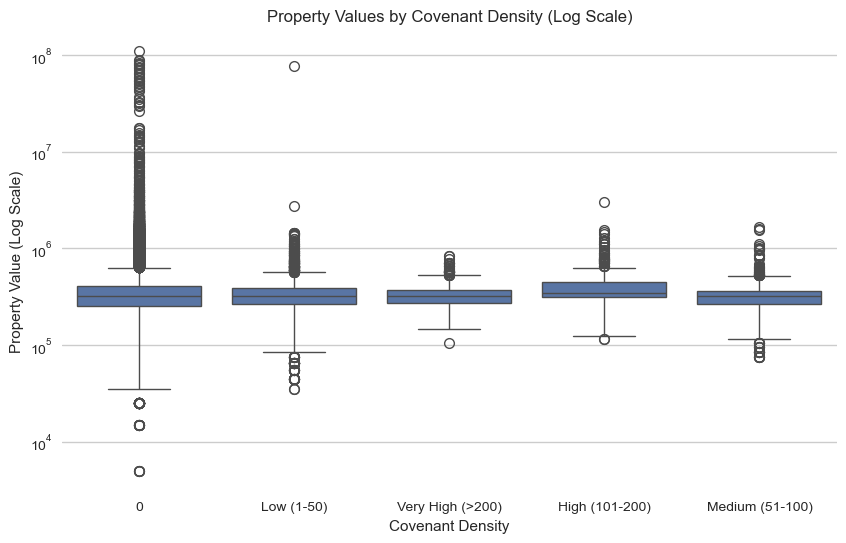

In [9]:
#Code Block 4
## visualization for property value vs. covenant density
if not os.path.exists('../../Analysis/Ramsey/figures'):
    os.makedirs('../../Analysis/Ramsey/figures')

plt.figure(figsize=(10,6))

sns.boxplot(data=data_clean, x='covenant_density', y='property_value')

plt.yscale('log')
plt.title("Property Values by Covenant Density (Log Scale)")
plt.xlabel("Covenant Density")
plt.ylabel("Property Value (Log Scale)")
## save the figure
plt.savefig('../../Analysis/Ramsey/figures/property_value_by_covenant_density.png', dpi=300, bbox_inches='tight')
plt.show()

derived_race
White               0.762089
Joint               0.748342
Asian               0.711270
Multiracial         0.664179
Native American     0.643796
Pacific Islander    0.615385
Black               0.608611
Unknown             0.407473
Name: was_approved, dtype: float64

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_51180/3598757125.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_clean, x='derived_race', y='was_approved', palette='viridis', order=data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False).index)


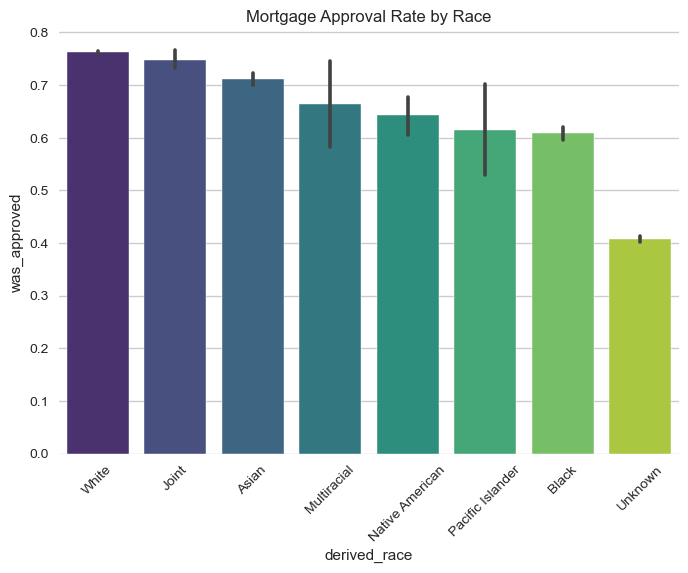

In [10]:
#Code Block 5
## approval rates grouped by derived race
race_clean_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "American Indian or Alaska Native": "Native American",
    "Native Hawaiian or Other Pacific Islander": "Pacific Islander",
    "2 or more minority races": "Multiracial",
    "Joint": "Joint",
    "Free Form Text Only": "Unknown",
    "Race Not Available": "Unknown"
}

data_clean['derived_race'] = data_clean['derived_race'].replace(race_clean_map)

display(data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False))

sns.barplot(data=data_clean, x='derived_race', y='was_approved', palette='viridis', order=data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False).index)
plt.title("Mortgage Approval Rate by Race")
plt.xticks(rotation=45)
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/mortgage_approval_rate_by_race.png", dpi=300, bbox_inches='tight')
plt.show()

Detect Proxy Variables

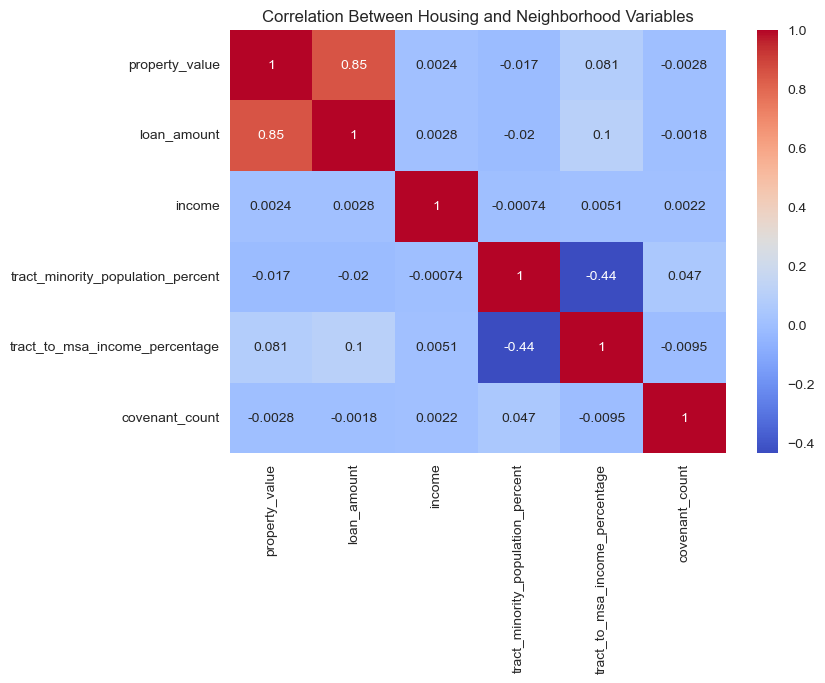

In [11]:
#Code Block 6
## correlation analysis for proxy variables

cols = [
    'property_value',
    'loan_amount',
    'income',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'covenant_count'
]

data_clean[cols].corr()

sns.heatmap(data_clean[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Housing and Neighborhood Variables")
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

Lending in Covenanted vs. Non-Covenanted Areas

has_covenants
False    0.669576
True     0.666186
Name: was_approved, dtype: float64

has_covenants
False    313137.898638
True     308837.656100
Name: loan_amount, dtype: float64

has_covenants
False    388454.355655
True     371277.617675
Name: property_value, dtype: float64

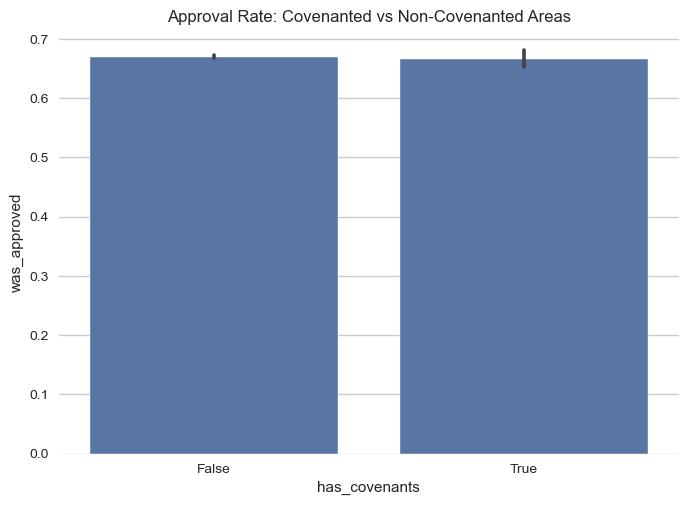

In [12]:
#Code Block 7
## compare lending in covenanted vs non-covenanted tracts

### binary variable for whether tract has any covenants
data_clean['has_covenants'] = data_clean['covenant_count'] > 0

### compare approval rates
display(data_clean.groupby('has_covenants')['was_approved'].mean())

### compare loan amounts
display(data_clean.groupby('has_covenants')['loan_amount'].mean())

### compare property values
display(data_clean.groupby('has_covenants')['property_value'].mean())

### visualize approval rates by covenant presence
sns.barplot(data=data_clean, x='has_covenants', y='was_approved')
plt.title("Approval Rate: Covenanted vs Non-Covenanted Areas")
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/approval_rate_by_covenant_presence.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_51180/606411016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_clean, x='covenant_density', y='was_approved', palette='viridis')


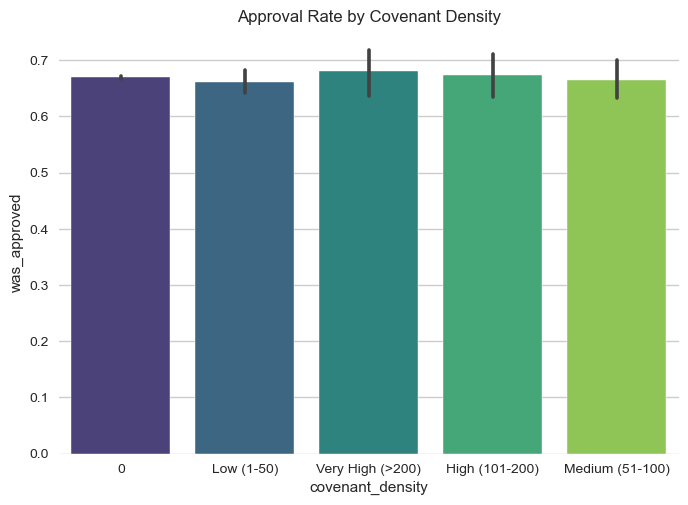

In [13]:
#Code Block 8
## approval rate based on covenant density categories
sns.barplot(data=data_clean, x='covenant_density', y='was_approved', palette='viridis')
plt.title("Approval Rate by Covenant Density")
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/approval_rate_by_covenant_density.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#Code Block 8
## pivot table for approval rates by race and covenant presence
column_order = ['0', 'Low (1-50)', 'Medium (51-100)', 'High (101-200)', 'Very High (>200)']

pivot_table = pd.pivot_table(
    data_clean,
    values='was_approved',
    index='derived_race',
    columns='covenant_density',
    aggfunc='mean'
)
pivot_table = pivot_table[column_order]
display(pivot_table)

covenant_density,0,Low (1-50),Medium (51-100),High (101-200),Very High (>200)
derived_race,,,,,
Asian,0.713083,0.691729,0.663717,0.726415,0.695652
Black,0.609721,0.571429,0.560000,0.642857,0.666667
Joint,0.744662,0.796610,0.913043,0.809524,0.785714
Multiracial,0.661538,1.000000,0.000000,NaN,NaN
Native American,0.637615,0.647059,1.000000,1.000000,0.857143
Pacific Islander,0.606061,1.000000,NaN,0.666667,NaN
Unknown,0.406813,0.435484,0.367647,0.437086,0.404580
White,0.762024,0.762336,0.756158,0.765886,0.776471


Logistic Regression

In [17]:
#Code Block 9
## logistic regression prep
import statsmodels.formula.api as smf
if not os.path.exists('../../Analysis/Ramsey/models'):
    os.makedirs('../../Analysis/Ramsey/models')

### drop missing interest rate values
data_model = data_clean.dropna(subset=['interest_rate'])
data_model['was_approved'] = data_model['was_approved'].astype(int)

model = smf.logit(formula = """
                  was_approved ~
                  C(derived_race) +
                  income +
                  loan_amount +
                  property_value +
                  interest_rate +
                  tract_minority_population_percent +
                  tract_to_msa_income_percentage +
                  covenant_count
                  """,
        data = data_model).fit()
## save the model
model.save('../../Analysis/Ramsey/models/logistic_regression_model.pkl')
print(model.summary())

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_51180/2570757341.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['was_approved'] = data_model['was_approved'].astype(int)


Optimization terminated successfully.
         Current function value: 0.368466
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                77877
Model:                          Logit   Df Residuals:                    77862
Method:                           MLE   Df Model:                           14
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.2679
Time:                        21:17:52   Log-Likelihood:                -28695.
converged:                       True   LL-Null:                       -39196.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               1.8995      0.098 

In [18]:
#Code Block 10
## extract odds ratios

odds_ratios = np.exp(model.params)
print(odds_ratios)

Intercept                              6.682830
C(derived_race)[T.Black]               0.522247
C(derived_race)[T.Joint]               0.821102
C(derived_race)[T.Multiracial]         1.145675
C(derived_race)[T.Native American]     0.763627
C(derived_race)[T.Pacific Islander]    0.324726
C(derived_race)[T.Unknown]             0.061049
C(derived_race)[T.White]               0.952227
income                                 1.008017
loan_amount                            0.999995
property_value                         1.000004
interest_rate                          0.992505
tract_minority_population_percent      0.996769
tract_to_msa_income_percentage         0.998402
covenant_count                         0.999585
dtype: float64


Logistic Regression for Covenant Density

In [19]:
#Code Block 11
## logistic regression with covenant density
model2 = smf.logit(
    """
    was_approved ~ 
    C(derived_race) +
    income +
    loan_amount +
    property_value +
    interest_rate +
    tract_minority_population_percent +
    tract_to_msa_income_percentage +
    C(covenant_density)
    """,
    data=data_model
).fit()

print(model2.summary())
## save the model
model2.save('../../Analysis/Ramsey/models/logistic_regression_cov_density.pkl')

odds_ratios = np.exp(model2.params)
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.368451
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                77877
Model:                          Logit   Df Residuals:                    77859
Method:                           MLE   Df Model:                           17
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.2679
Time:                        21:18:07   Log-Likelihood:                -28694.
converged:                       True   LL-Null:                       -39196.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.9036

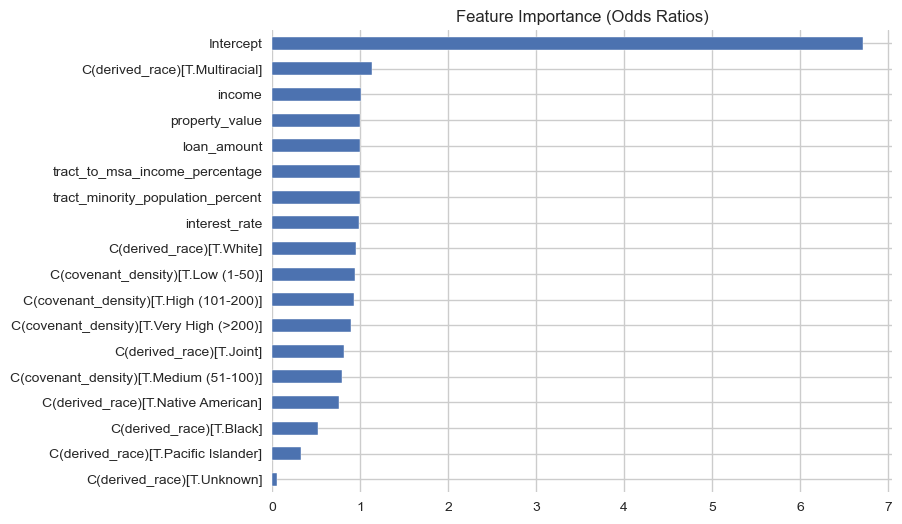

In [20]:
#Code Block 12
## feature importance analysis for log reg

odds_ratios.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Odds Ratios)")
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/feature_importance_odds_ratios.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
#Code Block 13
## check for multicollinearity with VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# select only numeric columns
X = data_clean.select_dtypes(include=['float64','int64'])

print(X.isna().sum())

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                  for i in range(len(X.columns))]

vif_data

activity_year                            0
census_tract                             0
action_taken                             0
loan_amount                              0
property_value                           0
income                                   0
interest_rate                        22082
tract_minority_population_percent        0
tract_to_msa_income_percentage           0
denial_reason-1                          0
covenant_count                           0
dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
0,activity_year,0.000000
1,census_tract,1.012135
2,action_taken,1.015738
3,loan_amount,20.899950
4,property_value,20.794139
5,income,1.087502
6,interest_rate,1.008528
7,tract_minority_population_percent,1.249054
8,tract_to_msa_income_percentage,1.315091
9,denial_reason-1,0.000000


## Data Bias

In [22]:
#Code Block 14
## property value disparities

print("\nAverage Property Value by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['property_value'].mean())

## income disparities
print("Average Income by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['income'].mean())

## racial distribution
print("Racial Distribution by Covenant Density:\n")
display(pd.crosstab(data_clean['derived_race'], data_clean['covenant_density']))
print("Racial Distribution by Covenant Density (Normalized):\n")
display(pd.crosstab(data_clean['derived_race'], data_clean['covenant_density'], normalize='columns'))

## loan size differences
print("Average Loan Amount by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['loan_amount'].mean())


Average Property Value by Covenant Density:



covenant_density
0                   388454.355655
High (101-200)      401563.011457
Low (1-50)          382422.455221
Medium (51-100)     331765.536723
Very High (>200)    342428.057554
Name: property_value, dtype: float64

Average Income by Covenant Density:



covenant_density
0                   126.465536
High (101-200)      142.520458
Low (1-50)          839.621669
Medium (51-100)     111.954802
Very High (>200)    112.821942
Name: income, dtype: float64

Racial Distribution by Covenant Density:



covenant_density,0,High (101-200),Low (1-50),Medium (51-100),Very High (>200)
derived_race,,,,,
Asian,5343,106,266,113,46
Black,4917,28,168,25,18
Joint,2295,21,59,23,14
Multiracial,130,0,3,1,0
Native American,654,3,17,4,7
Pacific Islander,99,3,2,0,0
Unknown,21666,151,558,136,131
White,60691,299,1216,406,340


Racial Distribution by Covenant Density (Normalized):



covenant_density,0,High (101-200),Low (1-50),Medium (51-100),Very High (>200)
derived_race,,,,,
Asian,0.055775,0.173486,0.116208,0.159605,0.082734
Black,0.051328,0.045827,0.073394,0.035311,0.032374
Joint,0.023957,0.034370,0.025775,0.032486,0.025180
Multiracial,0.001357,0.000000,0.001311,0.001412,0.000000
Native American,0.006827,0.004910,0.007427,0.005650,0.012590
Pacific Islander,0.001033,0.004910,0.000874,0.000000,0.000000
Unknown,0.226170,0.247136,0.243775,0.192090,0.235612
White,0.633551,0.489362,0.531236,0.573446,0.611511


Average Loan Amount by Covenant Density:



covenant_density
0                   313137.898638
High (101-200)      335261.865794
Low (1-50)          314178.680647
Medium (51-100)     290282.485876
Very High (>200)    281438.848921
Name: loan_amount, dtype: float64

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


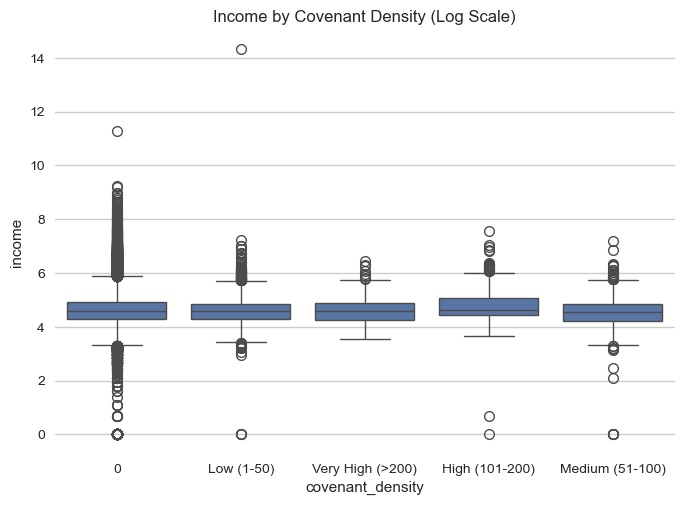

In [23]:
#Code Block 15
## visualization for income disparities

data_viz = data_clean.copy()
data_viz['income'] = np.log(data_viz['income'] + 1)
sns.boxplot(x='covenant_density', y='income', data=data_viz)
plt.title("Income by Covenant Density (Log Scale)")
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/income_by_covenant_density.png", dpi=300, bbox_inches='tight')
plt.show()

## Algorithmic Bias

In [24]:
#Code Block 16
## algorithmic bias analysis - does lending model reproduce or amplify inequalities

### approval rates by covenant density
print("\nApproval Rates by Covenant Density:\n")
display(data_clean.groupby('covenant_density')['was_approved'].mean())

### approval rates by race
print("Approval Rates by Race:\n")
display(data_clean.groupby('derived_race')['was_approved'].mean())


Approval Rates by Covenant Density:



covenant_density
0                   0.669576
High (101-200)      0.674304
Low (1-50)          0.660987
Medium (51-100)     0.665254
Very High (>200)    0.679856
Name: was_approved, dtype: float64

Approval Rates by Race:



derived_race
Asian               0.711270
Black               0.608611
Joint               0.748342
Multiracial         0.664179
Native American     0.643796
Pacific Islander    0.615385
Unknown             0.407473
White               0.762089
Name: was_approved, dtype: float64

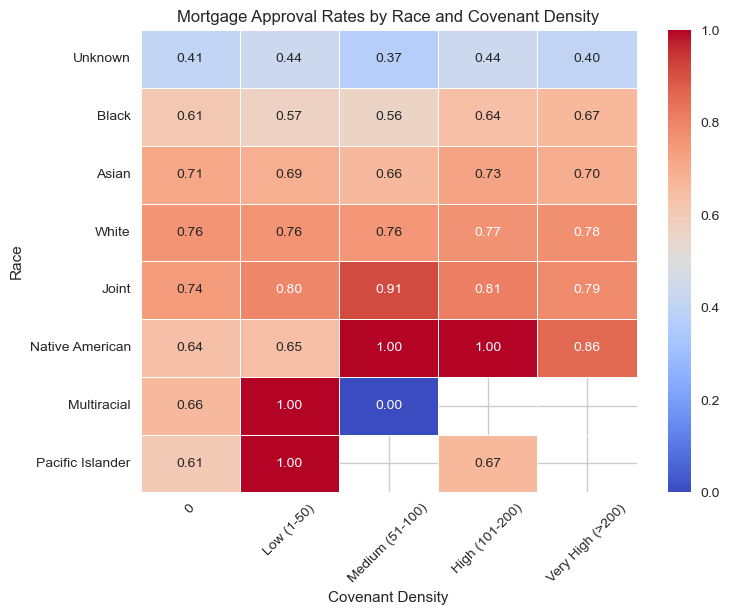

In [25]:
#Code Block 17
## visualization for approval rates by race and covenant density

plt.figure(figsize=(8,6))
pivot_table = pivot_table.sort_values(by=pivot_table.columns[-1])

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mortgage Approval Rates by Race and Covenant Density")
plt.xlabel("Covenant Density")
plt.xticks(rotation=45)
plt.ylabel("Race")
### save the figure
plt.savefig("../../Analysis/Ramsey/figures/approval_rates_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

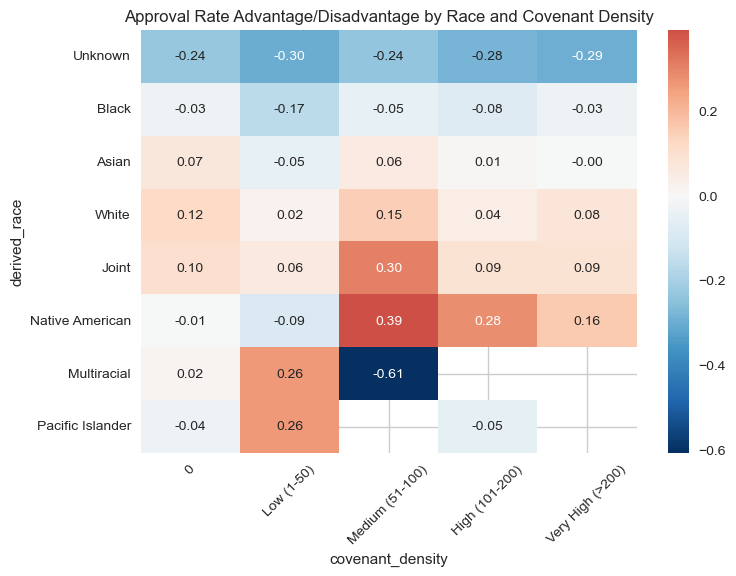

In [26]:
#Code Block 18
## pivot table advantage vs disadvantage analysis

pivot_diff = pivot_table - pivot_table.mean()

sns.heatmap(
    pivot_diff,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)
plt.xticks(rotation=45)
plt.title("Approval Rate Advantage/Disadvantage by Race and Covenant Density")
## save the figure
plt.savefig("../../Analysis/Ramsey/figures/approval_rate_advantage_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
#Code Block 19
## risk proxy investigation

data_clean[['covenant_count','property_value','income','loan_amount']].corr()

,covenant_count,property_value,income,loan_amount
covenant_count,1.000000,-0.002794,0.002199,-0.001786
property_value,-0.002794,1.000000,0.002444,0.849590
income,0.002199,0.002444,1.000000,0.002809
loan_amount,-0.001786,0.849590,0.002809,1.000000


## Full Logistic Regression Analysis

In [28]:
#Code Block 20
## examine the data

data_clean.info()
data_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99959 entries, 0 to 99958
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      99959 non-null  int64  
 1   census_tract                       99959 non-null  float64
 2   derived_race                       99959 non-null  object 
 3   action_taken                       99959 non-null  int64  
 4   loan_amount                        99959 non-null  float64
 5   property_value                     99959 non-null  float64
 6   income                             99959 non-null  float64
 7   interest_rate                      77877 non-null  float64
 8   tract_minority_population_percent  99959 non-null  float64
 9   tract_to_msa_income_percentage     99959 non-null  float64
 10  denial_reason-1                    99959 non-null  int64  
 11  covenant_count                     99959 non-null  flo

,activity_year,census_tract,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,99959.0,9.995900e+04,99959.000000,9.995900e+04,9.995900e+04,9.995900e+04,77877.000000,99959.000000,99959.000000,99959.000000,99959.000000
mean,2023.0,2.708025e+10,2.288538,3.129588e+05,3.877388e+05,1.427158e+02,6.574575,23.105170,102.845738,47.745976,4.128473
std,0.0,5.253963e+07,1.932969,7.784404e+05,1.108398e+06,5.230966e+03,1.272291,17.225087,30.862852,201.339954,37.733966
min,2023.0,2.700177e+10,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,2.030000,0.000000,1.000000,0.000000
25%,2023.0,2.703706e+10,1.000000,1.750000e+05,2.550000e+05,7.100000e+01,6.125000,10.250000,83.170000,10.000000,0.000000
50%,2023.0,2.705311e+10,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.800000,99.300000,10.000000,0.000000
75%,2023.0,2.712304e+10,4.000000,3.650000e+05,4.050000e+05,1.360000e+02,7.125000,29.780000,120.180000,10.000000,0.000000
max,2023.0,2.717397e+10,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.000000,95.630000,240.430000,1111.000000,849.000000


In [29]:
#Code Block 21
## cleaning data for analysis

data_model = data_clean.copy()
data_model = data_model.dropna(subset=['interest_rate'])

## important dummy variables

density_dummies = pd.get_dummies(data_model['covenant_density'], prefix='cd', drop_first=True)
race_dummies = pd.get_dummies(data_model['derived_race'], prefix='race', drop_first=True)
data_model = pd.concat([data_model, density_dummies, race_dummies], axis=1)

In [30]:
#Code Block 22
## baseline lending model

features_baseline = ['income', 'property_value', 'loan_amount', 'interest_rate'] + race_dummies.columns.tolist()
features_continuous = ['income', 'property_value', 'loan_amount', 'interest_rate'] + race_dummies.columns.tolist() + ['covenant_count']
features_density = ['income', 'property_value', 'loan_amount', 'interest_rate'] + race_dummies.columns.tolist() + density_dummies.columns.tolist()

## define target variable and features
y = data_model['was_approved']
X_base = data_model[features_baseline]
X_cont = data_model[features_continuous]
X_dens = data_model[features_density]

### Baseline Logistic Regression

In [31]:
#Code Block 23
## train/test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if not os.path.exists('../../Analysis/Ramsey/models/data'):
    os.makedirs('../../Analysis/Ramsey/models/data')

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

X_train1.to_csv('../../Analysis/Ramsey/models/data/X_train_baseline.csv', index=False)
X_test1.to_csv('../../Analysis/Ramsey/models/data/X_test_baseline.csv', index=False)
y_train1.to_csv('../../Analysis/Ramsey/models/data/y_train_baseline.csv', index=False)
y_test1.to_csv('../../Analysis/Ramsey/models/data/y_test_baseline.csv', index=False)


In [32]:
#Code Block 24
## scale the data and train the model
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)

lr_model1 = LogisticRegression(max_iter=1000, random_state=42)
lr_model1.fit(X_train1_scaled, y_train1)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
#Code Block 25
## evaluate the models accuracy
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

joblib.dump(lr_model1, '../../Analysis/Ramsey/models/lr_baseline.pkl')
y_pred1 = lr_model1.predict(X_test1_scaled)
print("Baseline Model Performance:")
print(classification_report(y_test1, y_pred1))
print("Confusion Matrix:")
print(confusion_matrix(y_test1, y_pred1))
print("Accuracy Score:", accuracy_score(y_test1, y_pred1))

Baseline Model Performance:
              precision    recall  f1-score   support

       False       0.65      0.60      0.63      3141
        True       0.90      0.92      0.91     12435

    accuracy                           0.86     15576
   macro avg       0.78      0.76      0.77     15576
weighted avg       0.85      0.86      0.85     15576

Confusion Matrix:
[[ 1898  1243]
 [ 1002 11433]]
Accuracy Score: 0.8558680020544427


Base Model Coefficients:
loan_amount             -3.454656
race_Unknown            -1.145338
race_Black              -0.131181
race_Pacific Islander   -0.037785
race_Joint              -0.021969
race_Native American    -0.018427
interest_rate           -0.011854
race_Multiracial         0.004601
race_White               0.009572
income                   1.140502
property_value           4.348528
dtype: float64


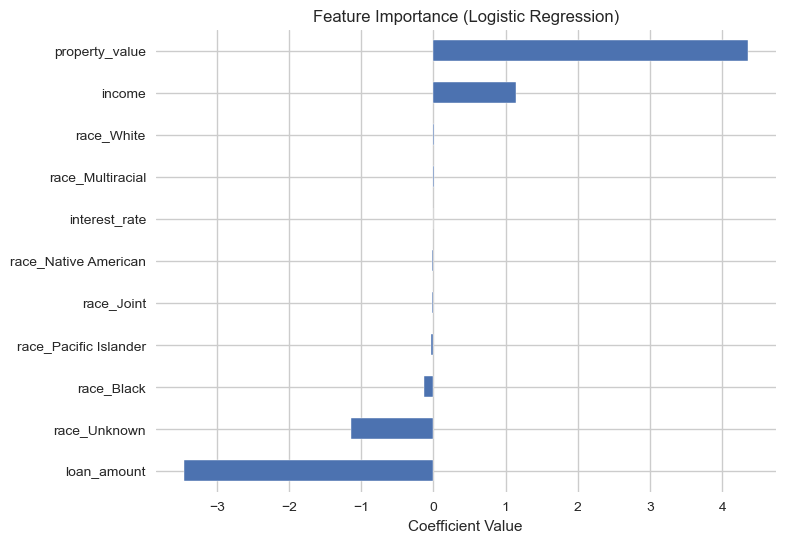

In [34]:
#Code Block 26
## feature importance for logistic regression baseline

coef_base = pd.Series(
    lr_model1.coef_[0],
    index=features_baseline
).sort_values()

print("Base Model Coefficients:")
print(coef_base)

coef_base.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/Ramsey/figures/lr_baseline_fi.png", dpi=300, bbox_inches='tight')
plt.show()

### Continuous Covenant Logistic Regression

In [35]:
#Code Block 27
## train/test split for model with covenant count

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_cont, y, test_size=0.2, random_state=42
)

X_train2.to_csv('../../Analysis/Ramsey/models/data/X_train_continuous.csv', index=False)
X_test2.to_csv('../../Analysis/Ramsey/models/data/X_test_continuous.csv', index=False)
y_train2.to_csv('../../Analysis/Ramsey/models/data/y_train_continuous.csv', index=False)
y_test2.to_csv('../../Analysis/Ramsey/models/data/y_test_continuous.csv', index=False)

In [36]:
#Code Block 28
## scale the data and train the model with covenant count

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

lr_model2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model2.fit(X_train2_scaled, y_train2)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
#Code Block 29
## evaluate the model with covenant count

joblib.dump(lr_model2, '../../Analysis/Ramsey/models/lr_continuous.pkl')
y_pred2 = lr_model2.predict(X_test2_scaled)
print("Continuous Model Performance:")
print(classification_report(y_test2, y_pred2))
print("Confusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))
print("Accuracy Score:", accuracy_score(y_test2, y_pred2))

Continuous Model Performance:
              precision    recall  f1-score   support

       False       0.65      0.60      0.63      3141
        True       0.90      0.92      0.91     12435

    accuracy                           0.86     15576
   macro avg       0.78      0.76      0.77     15576
weighted avg       0.85      0.86      0.85     15576

Confusion Matrix:
[[ 1898  1243]
 [ 1001 11434]]
Accuracy Score: 0.8559322033898306


Continuous Model Coefficients:
loan_amount             -3.471826
race_Unknown            -1.147731
race_Black              -0.132356
race_Pacific Islander   -0.037838
race_Joint              -0.022578
race_Native American    -0.018452
covenant_count          -0.015693
interest_rate           -0.011505
race_Multiracial         0.004411
race_White               0.007407
income                   1.140336
property_value           4.369549
dtype: float64


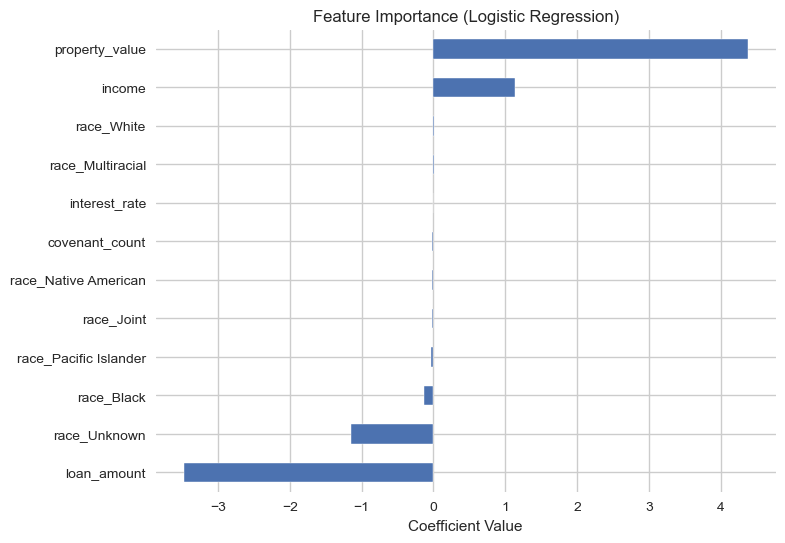

In [38]:
#Code Block 30
## feature importance for logistic regression continuous

coef_continuous = pd.Series(
    lr_model2.coef_[0],
    index=features_continuous
).sort_values()

print("Continuous Model Coefficients:")
print(coef_continuous)

coef_continuous.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/Ramsey/figures/lr_continuous_fi.png", dpi=300, bbox_inches='tight')
plt.show()

### Covenant Density Logistic Regression

In [39]:
#Code Block 31
## train/test split for model with covenant density

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_dens, y, test_size=0.2, random_state=42
)

X_train3.to_csv('../../Analysis/Ramsey/models/data/X_train_density.csv', index=False)
X_test3.to_csv('../../Analysis/Ramsey/models/data/X_test_density.csv', index=False)
y_train3.to_csv('../../Analysis/Ramsey/models/data/y_train_density.csv', index=False)
y_test3.to_csv('../../Analysis/Ramsey/models/data/y_test_density.csv', index=False)

In [40]:
#Code Block 32
## scale the data and train the model with covenant density

scaler = StandardScaler()
X_train3_scaled = scaler.fit_transform(X_train3)
X_test3_scaled = scaler.transform(X_test3)

lr_model3 = LogisticRegression(max_iter=1000, random_state=42)
lr_model3.fit(X_train3_scaled, y_train3)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
#Code Block 33
## evaluate the model with covenant density

joblib.dump(lr_model3, '../../Analysis/Ramsey/models/lr_density.pkl')
y_pred3 = lr_model3.predict(X_test3_scaled)
print("Density Model Performance:")
print(classification_report(y_test3, y_pred3))
print("Confusion Matrix:")
print(confusion_matrix(y_test3, y_pred3))
print("Accuracy Score:", accuracy_score(y_test3, y_pred3))

Density Model Performance:
              precision    recall  f1-score   support

       False       0.66      0.60      0.63      3141
        True       0.90      0.92      0.91     12435

    accuracy                           0.86     15576
   macro avg       0.78      0.76      0.77     15576
weighted avg       0.85      0.86      0.85     15576

Confusion Matrix:
[[ 1900  1241]
 [ 1000 11435]]
Accuracy Score: 0.8561248073959938


Density Model Coefficients:
loan_amount             -3.470841
race_Unknown            -1.150318
race_Black              -0.133632
race_Pacific Islander   -0.038152
race_Joint              -0.023345
cd_Medium (51-100)      -0.019567
race_Native American    -0.018965
interest_rate           -0.011474
cd_Very High (>200)     -0.009076
cd_Low (1-50)           -0.008518
cd_High (101-200)       -0.004035
race_Multiracial         0.004165
race_White               0.004515
income                   1.139897
property_value           4.367502
dtype: float64


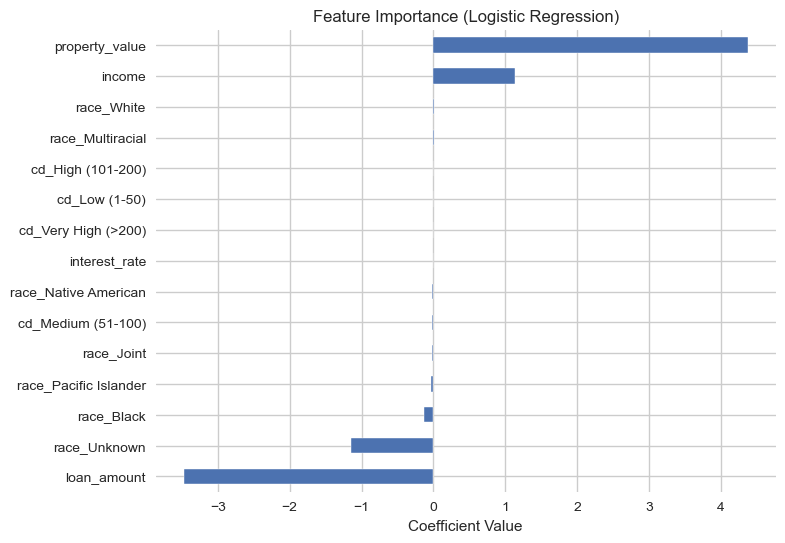

In [42]:
#Code Block 34
## feature importance for logistic regression density

coef_density = pd.Series(
    lr_model3.coef_[0],
    index=features_density
).sort_values()

print("Density Model Coefficients:")
print(coef_density)

coef_density.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/Ramsey/figures/lr_density_fi.png", dpi=300, bbox_inches='tight')
plt.show()

### Interaction Effect

In [43]:
#Code Block 35
## features for interaction model

data_model['black_high_density'] = data_model['race_Black'] * data_model['cd_High (101-200)']
data_model['black_vhigh_density'] = data_model['race_Black'] * data_model['cd_Very High (>200)']
features_int = ['income', 'property_value', 'loan_amount', 'interest_rate', 'black_high_density', 'black_vhigh_density'] + race_dummies.columns.tolist() + density_dummies.columns.tolist()

## define target variable and features
y = data_model['was_approved']
X_int = data_model[features_int]

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_int, y, test_size=0.2, random_state=42
)

X_train4.to_csv('../../Analysis/Ramsey/models/data/X_train_interaction.csv', index=False)
X_test4.to_csv('../../Analysis/Ramsey/models/data/X_test_interaction.csv', index=False)
y_train4.to_csv('../../Analysis/Ramsey/models/data/y_train_interaction.csv', index=False)
y_test4.to_csv('../../Analysis/Ramsey/models/data/y_test_interaction.csv', index=False)

In [44]:
#Code Block 36
## scale the data and train the model with covenant density

scaler = StandardScaler()
X_train4_scaled = scaler.fit_transform(X_train4)
X_test4_scaled = scaler.transform(X_test4)

lr_model4 = LogisticRegression(max_iter=1000, random_state=42)
lr_model4.fit(X_train4_scaled, y_train4)

LogisticRegression(max_iter=1000, random_state=42)

In [45]:
#Code Block 37
## evaluate the model with interaction terms

joblib.dump(lr_model4, '../../Analysis/Ramsey/models/lr_interaction.pkl')
y_pred4 = lr_model4.predict(X_test4_scaled)
print("Interaction Model Performance:")
print(classification_report(y_test4, y_pred4))
print("Confusion Matrix:")
print(confusion_matrix(y_test4, y_pred4))
print("Accuracy Score:", accuracy_score(y_test4, y_pred4))

Interaction Model Performance:
              precision    recall  f1-score   support

       False       0.66      0.60      0.63      3141
        True       0.90      0.92      0.91     12435

    accuracy                           0.86     15576
   macro avg       0.78      0.76      0.77     15576
weighted avg       0.85      0.86      0.85     15576

Confusion Matrix:
[[ 1900  1241]
 [ 1000 11435]]
Accuracy Score: 0.8561248073959938


Interaction Model Coefficients:
loan_amount             -3.483935
race_Unknown            -1.151111
race_Black              -0.133768
race_Pacific Islander   -0.038398
race_Joint              -0.023621
cd_Medium (51-100)      -0.019494
race_Native American    -0.019151
black_high_density      -0.013411
cd_Very High (>200)     -0.011432
interest_rate           -0.011281
cd_Low (1-50)           -0.008479
cd_High (101-200)        0.000512
race_White               0.002878
race_Multiracial         0.004060
black_vhigh_density      0.014499
income                   1.134692
property_value           4.382790
dtype: float64


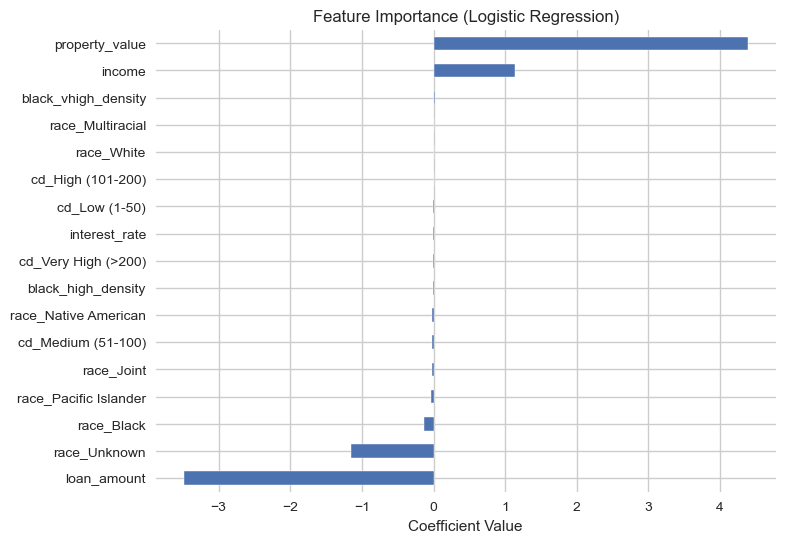

In [46]:
#Code Block 38
## feature importance for logistic regression with interaction terms

coef_interaction = pd.Series(
    lr_model4.coef_[0],
    index=features_int
).sort_values()

print("Interaction Model Coefficients:")
print(coef_interaction)

coef_interaction.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("../../Analysis/Ramsey/figures/lr_interaction_fi.png", dpi=300, bbox_inches='tight')
plt.show()